In [1]:
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings

plt.style.use('fivethirtyeight')
mpl.rc('patch', edgecolor='dimgray', linewidth=1)

warnings.filterwarnings("ignore")

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
# Example dataset (you can replace with your CSV)
df = pd.read_csv("wine.csv")

print(df.head())
print(df.info())
print(df.describe())

   Wine  Alcohol  Malic.acid   Ash   Acl   Mg  Phenols  Flavanoids  \
0     1    14.23        1.71  2.43  15.6  127     2.80        3.06   
1     1    13.20        1.78  2.14  11.2  100     2.65        2.76   
2     1    13.16        2.36  2.67  18.6  101     2.80        3.24   
3     1    14.37        1.95  2.50  16.8  113     3.85        3.49   
4     1    13.24        2.59  2.87  21.0  118     2.80        2.69   

   Nonflavanoid.phenols  Proanth  Color.int   Hue    OD  Proline  
0                  0.28     2.29       5.64  1.04  3.92     1065  
1                  0.26     1.28       4.38  1.05  3.40     1050  
2                  0.30     2.81       5.68  1.03  3.17     1185  
3                  0.24     2.18       7.80  0.86  3.45     1480  
4                  0.39     1.82       4.32  1.04  2.93      735  
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                -----

In [9]:
print(df.columns)

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='str')


In [11]:
X = df.drop("Wine", axis=1)   # features
y = df["Wine"]                # target

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')   # 3 classes (Wine)
])

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
y = df["Wine"] - 1

In [20]:
# Features & target
X = df.drop("Wine", axis=1)
y = df["Wine"] - 1

In [21]:
# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3186 - loss: 1.0499 - val_accuracy: 0.6207 - val_loss: 0.8437
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6106 - loss: 0.8660 - val_accuracy: 0.7931 - val_loss: 0.7074
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8142 - loss: 0.7238 - val_accuracy: 0.8621 - val_loss: 0.5889
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8850 - loss: 0.6053 - val_accuracy: 0.8966 - val_loss: 0.4848
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9558 - loss: 0.5045 - val_accuracy: 0.9310 - val_loss: 0.3957
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9646 - loss: 0.4241 - val_accuracy: 0.9655 - val_loss: 0.3220
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9558 - loss: 0.3546 - val_accuracy: 1.0000 - val_loss: 0.2561
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9646 - loss: 0.2902 - val_accuracy: 1.0000 - val_loss: 0.2035


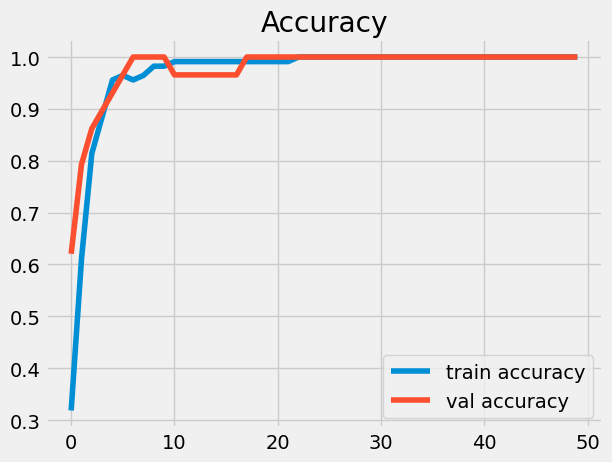

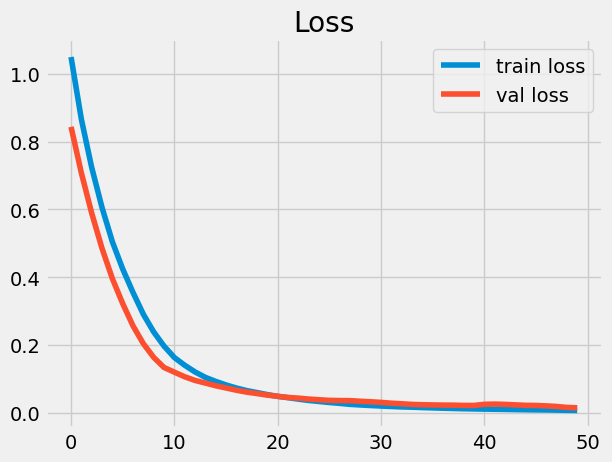

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [25]:
pred = model.predict(X_test)
pred_classes = pred.argmax(axis=1)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, pred_classes))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Accuracy: 1.0


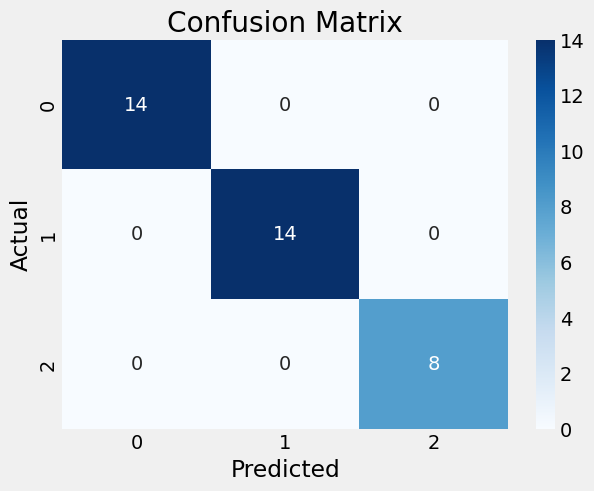

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred_classes)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [29]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [32]:
print(y_train[:10])
print(type(y_train))

158    2
137    2
98     1
159    2
38     0
108    1
85     1
68     1
143    2
2      0
Name: Wine, dtype: int64
<class 'pandas.Series'>


In [33]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [34]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6637 - loss: 0.9118 - val_accuracy: 0.8966 - val_loss: 0.7228
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8673 - loss: 0.6849 - val_accuracy: 0.9310 - val_loss: 0.5267
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9115 - loss: 0.5137 - val_accuracy: 0.9655 - val_loss: 0.3963
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9469 - loss: 0.3636 - val_accuracy: 0.9655 - val_loss: 0.3012
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9558 - loss: 0.3079 - val_accuracy: 0.9655 - val_loss: 0.2315
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9823 - loss: 0.2248 - val_accuracy: 0.9655 - val_loss: 0.1795
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9381 - loss: 0.2084 - val_accuracy: 0.9655 - val_loss: 0.1477
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9646 - loss: 0.1608 - val_accuracy: 0.9655 - val_loss: 0.1232


In [36]:
loss, acc = model.evaluate(X_test, y_test)
print("Test loss:", loss)
print("Test accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.0120
Test loss: 0.011990178376436234
Test accuracy: 1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


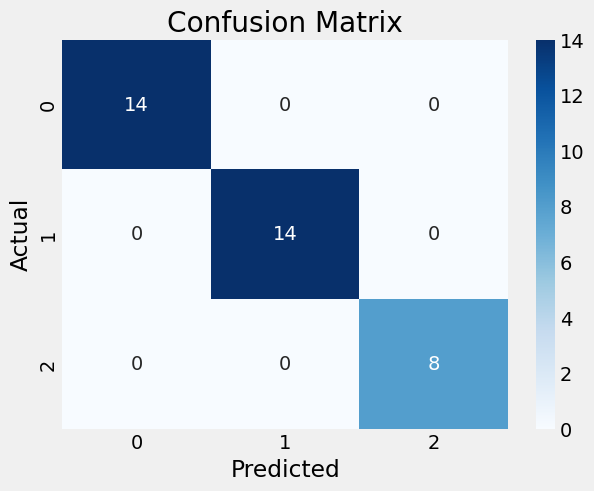

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

pred = model.predict(X_test)
pred_classes = pred.argmax(axis=1)

cm = confusion_matrix(y_test, pred_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, pred_classes))

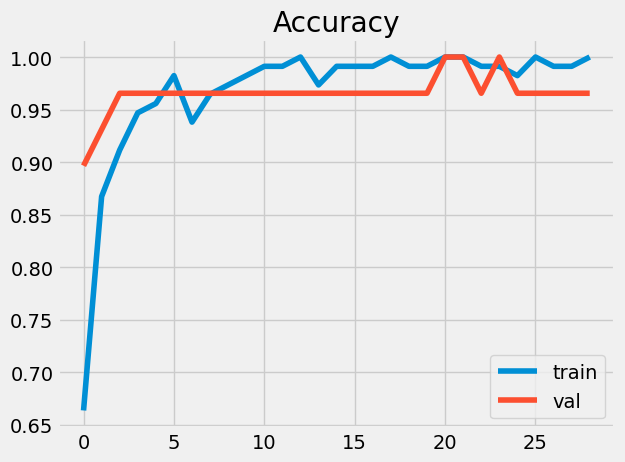

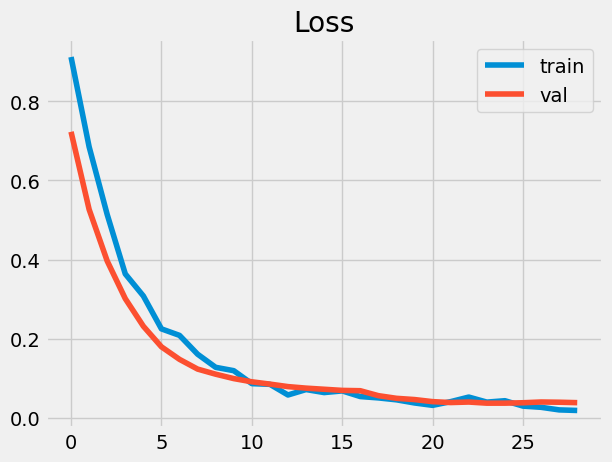

In [38]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [39]:
model.save("wine_model.h5")

In [40]:
from tensorflow.keras.models import load_model
model = load_model("wine_model.h5")

In [41]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

In [43]:
epochs = 100
batch_size = 16

In [44]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

In [45]:
def create_model(neurons1=64, neurons2=32, dropout1=0.3, dropout2=0.2):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout

    model = Sequential([
        Dense(neurons1, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(dropout1),
        Dense(neurons2, activation='relu'),
        Dropout(dropout2),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [46]:
results = []

In [47]:
model1 = create_model(64, 32)

history1 = model1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)
results.append(("64-32", acc1))

In [48]:
model2 = create_model(128, 64)

history2 = model2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)
results.append(("128-64", acc2))

In [49]:
model3 = create_model(256, 128)

history3 = model3.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)
results.append(("256-128", acc3))

In [50]:
for name, acc in results:
    print(f"Model {name} → Accuracy: {acc:.4f}")

Model 64-32 → Accuracy: 1.0000
Model 128-64 → Accuracy: 1.0000
Model 256-128 → Accuracy: 1.0000


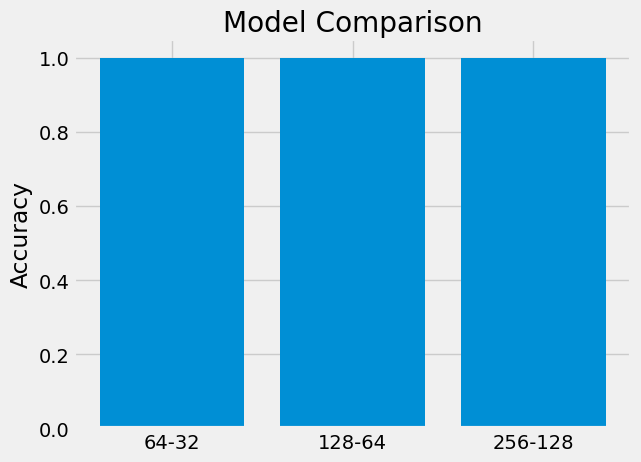

In [51]:
import matplotlib.pyplot as plt

names = [r[0] for r in results]
accs = [r[1] for r in results]

plt.bar(names, accs)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [52]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [53]:
callbacks=[early_stop]

